In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

from models.timeseries import load_training_df

from datetime import datetime, timedelta
from seaborn import set_style
set_style("whitegrid")

In [2]:
daily = load_training_df()

## The variable we want to model - daily generated power by wind farms

Text(0.5, 0, 'Date')

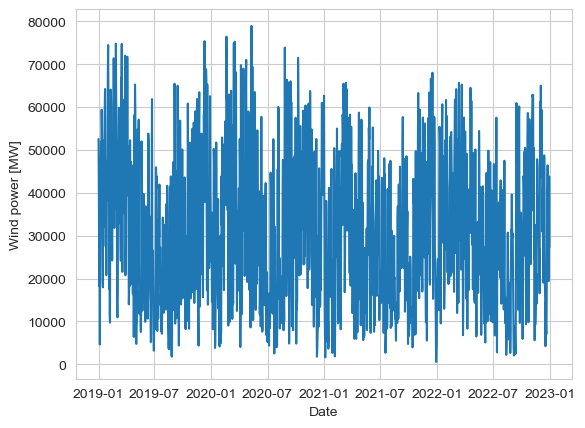

In [3]:
plt.plot(daily.Wind)
plt.ylabel('Wind power [MW]')
plt.xlabel('Date')

The goal is to model the total daily power generated by wind farms. There are 39 wind farms in service across Quebec. Only the total wind power generated is available. Weather data is also available for each wind farm location separately (wind speed, temperature, humidity). Looking at the distribution of wind power generated over the years, the data is very noisy, with potentially some seasonality. Looking at each year separately:

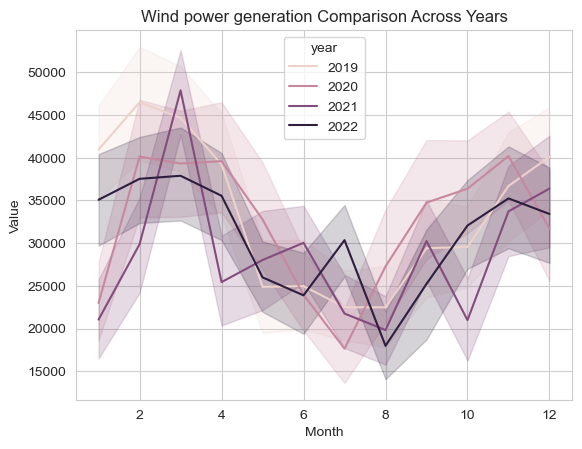

In [4]:
sns.lineplot(x='month', y='Wind', hue='year', data=daily)
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Wind power generation Comparison Across Years')
plt.show()

The peak production is usually in March, with minimum in July. Still, there is variation for different years.

Now looking at the dependancy on weather variables; the weather variables have been averaged by day across all locations 

Text(0, 0.5, 'Wind power [MW]')

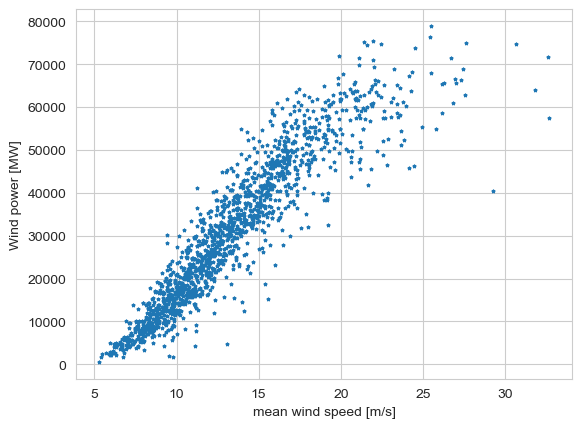

In [5]:
plt.scatter(x=daily.mean_windspeed, y=daily.Wind, marker='*', s=5)
plt.xlabel('mean wind speed [m/s]')
plt.ylabel('Wind power [MW]')

There is a strong dependence on the average wind speed.

Text(0, 0.5, 'Wind power [MW]')

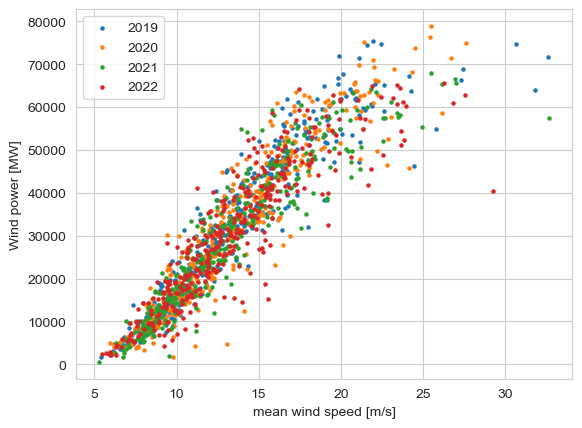

In [6]:
for year in[2020, 2021, 2022, 2023]:
    plt.scatter(daily.query(f'{year-1}<time<{year}').mean_windspeed, daily.query(f'{year - 1}<time<{year}').Wind, label=f'{year-1}', s=5)
plt.legend()
plt.xlabel('mean wind speed [m/s]')
plt.ylabel('Wind power [MW]')

The distributions for each available year look similar.

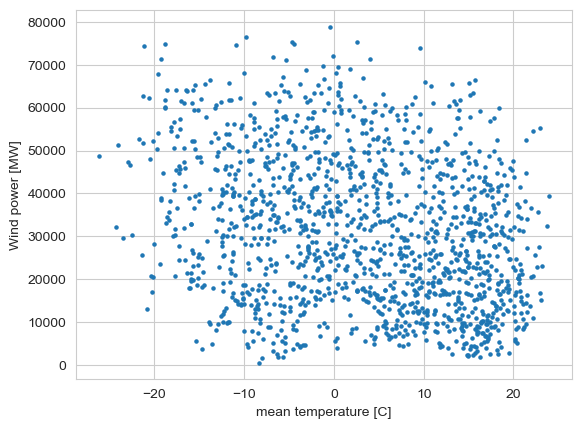

In [7]:
plt.scatter(x=daily['mean_temperature'], y=daily.Wind, s=5)
plt.xlabel('mean temperature [C]')
plt.ylabel('Wind power [MW]')
plt.show()

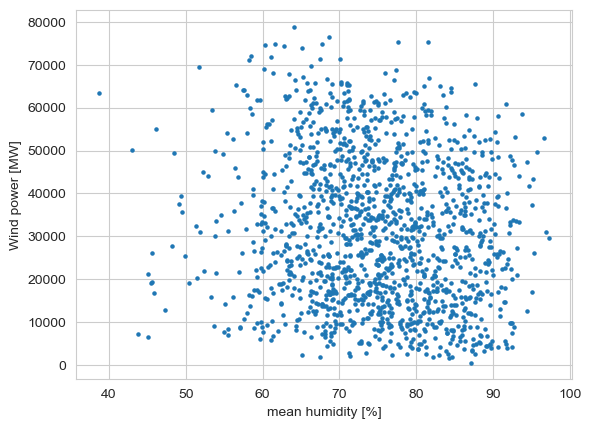

In [8]:
plt.scatter(x=daily['mean_humidity'], y=daily.Wind, s=5)
plt.xlabel('mean humidity [%]')
plt.ylabel('Wind power [MW]')
plt.show()

Looking at the plots, there is no obvious dependence on mean temperature and humidity.

Text(0, 0.5, 'Wind power [MW]')

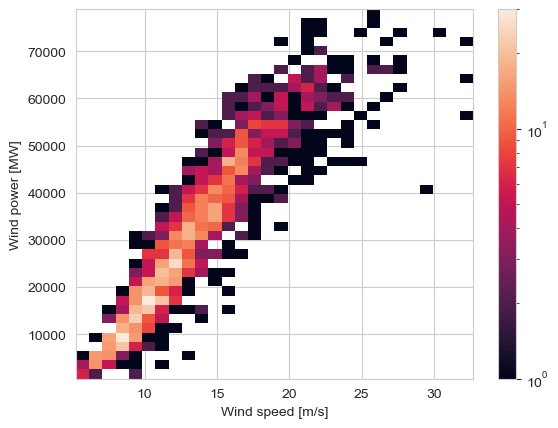

In [9]:
import matplotlib as mpl
fig, ax = plt.subplots()
h = ax.hist2d(x=daily.mean_windspeed, y=daily.Wind, bins=[30, 40], norm=mpl.colors.LogNorm(),)
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('Wind speed [m/s]')
ax.set_ylabel('Wind power [MW]')

Looking at wind speed cubed: 

Text(0, 0.5, 'Wind power')

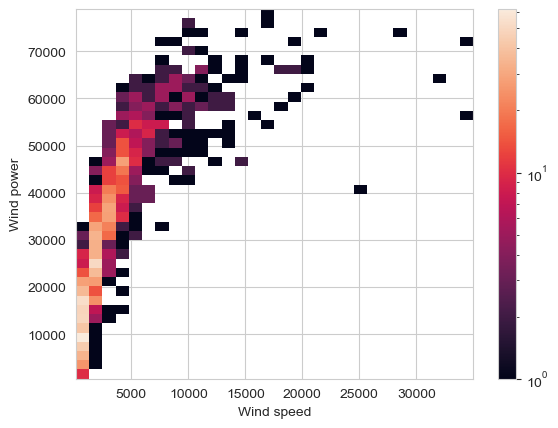

In [10]:
import matplotlib as mpl
fig, ax = plt.subplots()
h = ax.hist2d(x=daily.mean_windspeed**3, y=daily.Wind, bins=[30, 40], norm=mpl.colors.LogNorm(),)
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('Wind speed')
ax.set_ylabel('Wind power')

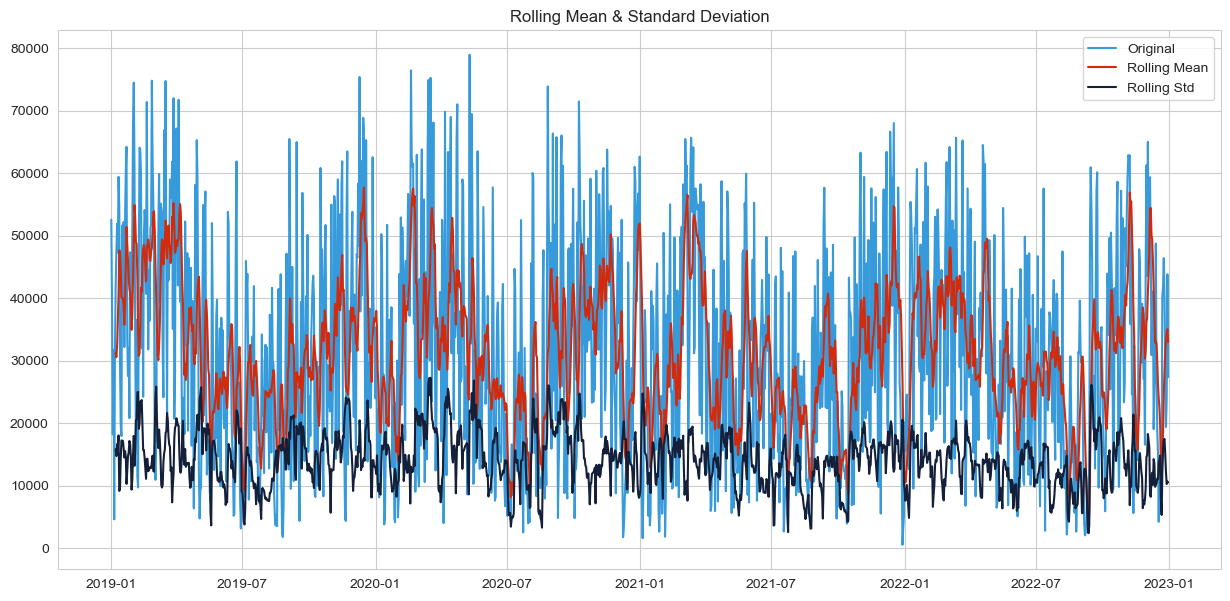

In [11]:
#Determine rolling statistics
daily["rolling_avg"] = daily["Wind"].rolling(window=7).mean() #window size 7 denotes 7 days, giving rolling mean at weekly level
daily["rolling_std"] = daily["Wind"].rolling(window=7).std()

#Plot rolling statistics
plt.figure(figsize=(15,7))
plt.plot(daily["Wind"], color='#379BDB', label='Original')
plt.plot(daily["rolling_avg"], color='#D22A0D', label='Rolling Mean')
plt.plot(daily["rolling_std"], color='#142039', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

## Augmented Dickey–Fuller Test

The Augmented Dickey-Fuller Test is used to determine if time-series data is stationary or not.

Null Hypothesis: The data is not stationary.
Alternative Hypothesis: The data is stationary.

For the data to be stationary (ie. reject the null hypothesis), the ADF test should have:

    p-value <= significance level (0.01, 0.05, 0.10, etc.)

If the p-value is greater than the significance level then we can say that it is likely that the data is not stationary.

In [12]:
#Augmented Dickey–Fuller test, full dataset:
from statsmodels.tsa.stattools import adfuller

print('Results of Dickey Fuller Test:')
dftest = adfuller(daily['Wind'], autolag='t-stat')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value


print(dfoutput)

Results of Dickey Fuller Test:
Test Statistic                   -4.958653
p-value                           0.000027
#Lags Used                       23.000000
Number of Observations Used    1437.000000
Critical Value (1%)              -3.434909
Critical Value (5%)              -2.863553
Critical Value (10%)             -2.567842
dtype: float64


In [13]:
#Looking at just 30 days interval:
print('Results of Dickey Fuller Test:')
dftest = adfuller(daily.iloc[-30:]['Wind'], autolag='t-stat')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value

print(dfoutput)

Results of Dickey Fuller Test:
Test Statistic                 -2.318942
p-value                         0.165931
#Lags Used                      0.000000
Number of Observations Used    29.000000
Critical Value (1%)            -3.679060
Critical Value (5%)            -2.967882
Critical Value (10%)           -2.623158
dtype: float64


While the full dataset has p-value close to 0, the 30 day interval (shown here for the last 30 days in the dataframe) have p-value high enough to accept the null hypothesis that the data is not stationary.

In [14]:
from pmdarima.arima.stationarity import ADFTest

adf_test = ADFTest(alpha=0.05)
p_val, should_diff = adf_test.should_diff(daily[-30:].Wind)
print(p_val, should_diff)

0.5958934641047493 True


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

In [15]:
from pmdarima.arima.utils import ndiffs

n_adf = ndiffs(daily[-61:-30].Wind, test='adf')
print(n_adf)

2


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

In [16]:
from pmdarima.arima.utils import ndiffs

n_adf = ndiffs(daily[-30:].Wind, test='adf')
print(n_adf)

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

2


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

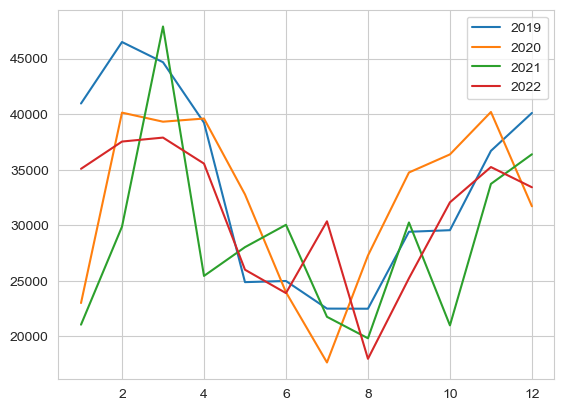

In [17]:
for year in[2020, 2021, 2022, 2023]:
    plt.plot(np.linspace(1, 12, 12), daily.resample('ME').mean().query(f'{year - 1}<time<{year}').Wind, label=f'{year-1}')
plt.legend()

# Autocorrelation

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima.utils import c, diff

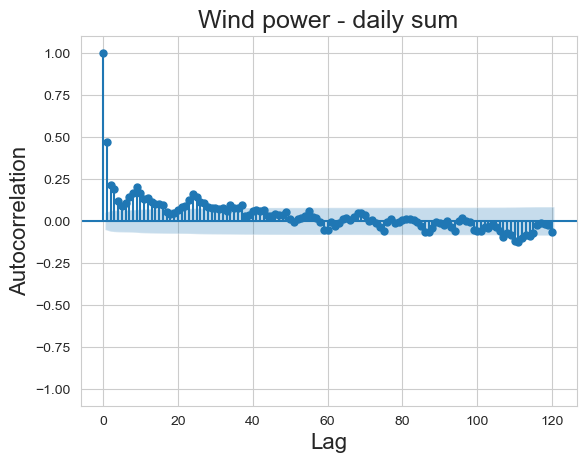

In [19]:
## first put in the time series
## then set how many lags you want to consider
## the default is lags=30
sm.graphics.tsa.plot_acf(daily.Wind,
                            lags = 120)

plt.title('Wind power - daily sum', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

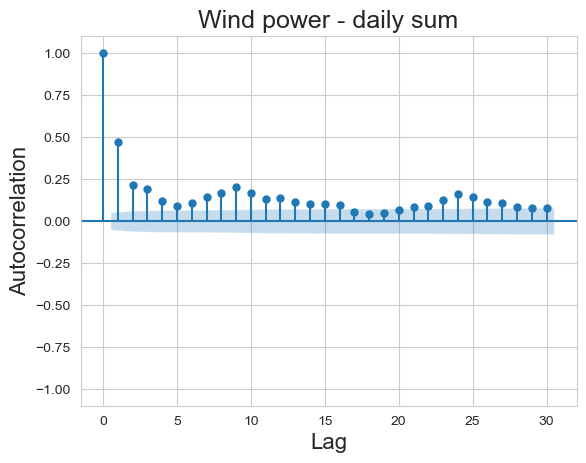

In [20]:
## first put in the time series
## then set how many lags you want to consider
## the default is lags=30
sm.graphics.tsa.plot_acf(daily.Wind,
                            lags = 30)

plt.title('Wind power - daily sum', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

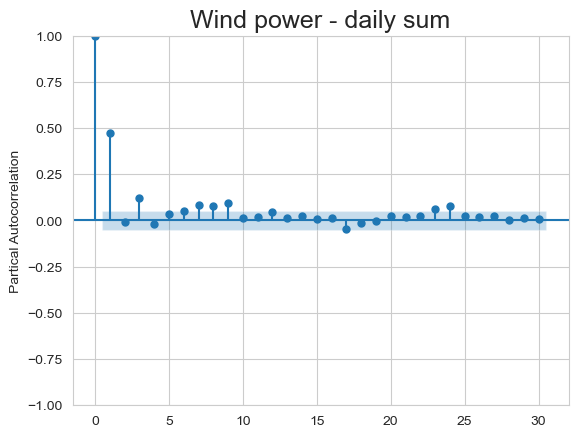

In [21]:
sm.graphics.tsa.plot_pacf(daily.Wind, lags=30, method='ols')
plt.title('Wind power - daily sum', fontsize=18)
plt.ylabel('Partical Autocorrelation')
plt.show()

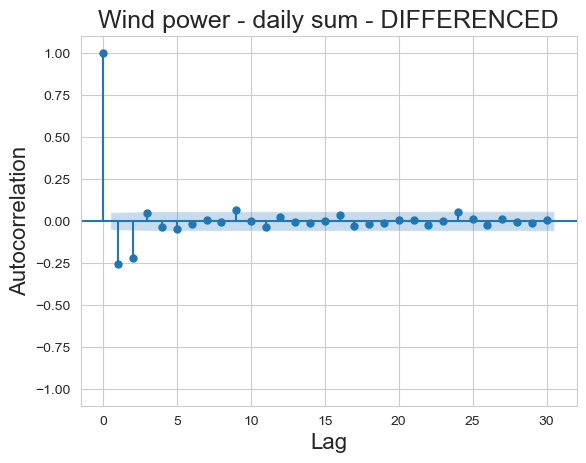

In [22]:
## differenced daily
sm.graphics.tsa.plot_acf(daily.Wind.diff().dropna(),
                            lags = 30)

plt.title('Wind power - daily sum - DIFFERENCED', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

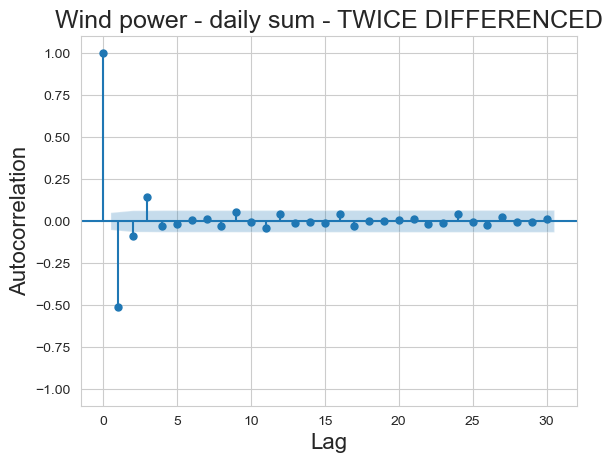

In [23]:
## differenced daily
sm.graphics.tsa.plot_acf(diff(daily.Wind.values, differences=2),
                            lags = 30)

plt.title('Wind power - daily sum - TWICE DIFFERENCED', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

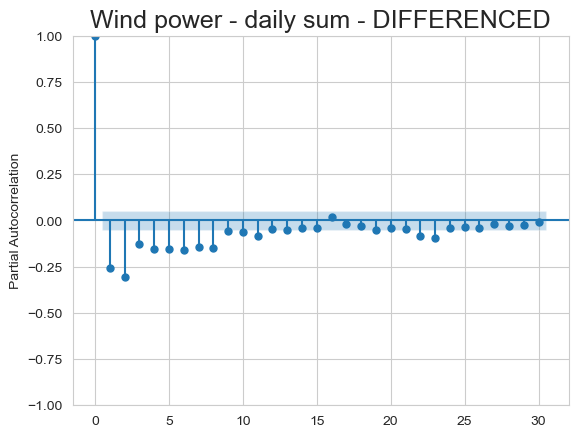

In [24]:
sm.graphics.tsa.plot_pacf(diff(daily.Wind.values, differences=1), lags=30, method='ols')
plt.title('Wind power - daily sum - DIFFERENCED', fontsize=18)
plt.ylabel('Partial Autocorrelation')
plt.show()

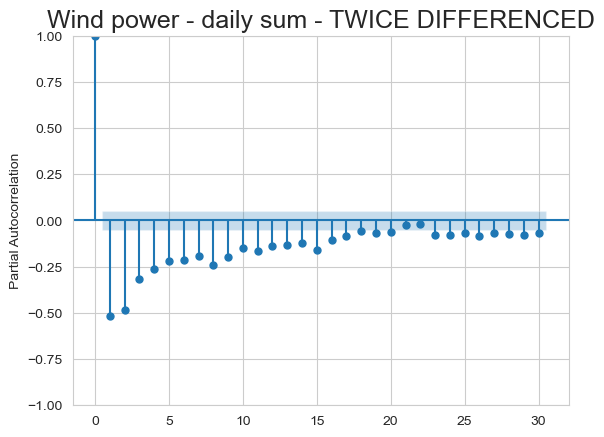

In [25]:
sm.graphics.tsa.plot_pacf(diff(daily.Wind.values, differences=2), lags=30, method='ols')
plt.title('Wind power - daily sum - TWICE DIFFERENCED', fontsize=18)
plt.ylabel('Partial Autocorrelation')
plt.show()

In [26]:
from pmdarima import ARIMA
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import r2_score

Based on the autocorrelation plots, trying ARIMA(0, 1, 3)

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/andreafodor/a

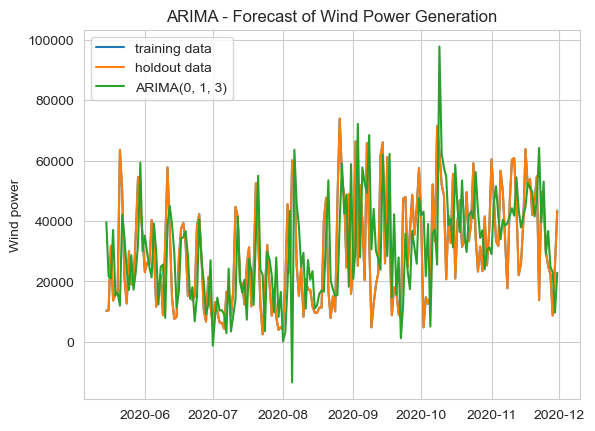

MAPE:  0.715382181909403
r2  -0.09874985309294315


In [27]:
forecast30 = []
mses30 = []
mape30 = []

for i in range(500, 700):
    sfm30 = ARIMA(order=(0, 1, 3))
    sfm30_fit = sfm30.fit(daily.iloc[i-30:i].Wind,)
    fcst = sfm30_fit.predict(n_periods=1)
    forecast30.append(fcst.values)
    mses30.append(mse(np.array(daily.iloc[i][['Wind']]), fcst))
    mape30.append(mape(np.array(daily.iloc[i][['Wind']]), fcst))

plt.plot(daily.index[500:700], daily.Wind.iloc[500:700], label = 'training data')
plt.plot(daily.index[500:700], daily.Wind.iloc[500:700], label = 'holdout data')
plt.plot(daily.index[500:700], forecast30, label = 'ARIMA(0, 1, 3)')

plt.title("ARIMA - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(mape30))  
print('r2 ', r2_score(daily.iloc[500:700].Wind, forecast30))  

This method seems to have convergence issues sometimes and MAPE and r2 are bad.

In [28]:
from pmdarima import auto_arima
auto_arima(daily[-30:].Wind, trace=True)

Performing stepwise search to minimize aic


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=659.950, Time=0.42 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=669.494, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=653.633, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=659.172, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=716.882, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=655.888, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=655.941, Time=0.05 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=657.930, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=658.107, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.717 seconds


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ARIMA(order=(1, 0, 0), scoring_args={}, suppress_warnings=True)

In [29]:
import statsmodels.tsa.api as sm
# This is how we fit the model
model = sm.ARIMA(daily[-31:-1].Wind, order = (1, 0, 0)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   Wind   No. Observations:                   30
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -324.756
Date:                Fri, 27 Jun 2025   AIC                            655.511
Time:                        19:25:51   BIC                            659.715
Sample:                    12-01-2022   HQIC                           656.856
                         - 12-30-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.362e+04   6063.393      5.545      0.000    2.17e+04    4.55e+04
ar.L1          0.7069      0.144      4.898      0.000       0.424       0.990
sigma2      1.356e+08      0.336   4.03e+08      0.000    1.36e+08    1.36e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.41   Jarque-Bera (JB):                 1.61
Prob(Q):                              0.52   Prob(JB):                         0.45
Heteroskedasticity (H):               0.64   Skew:                             0.38
Prob(H) (two-sided):                  0.49   Kurtosis:                         2.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.65e+24. Standard errors may be unstable.
"""

In [30]:
print(daily[-1:].Wind)
print(model.forecast(1))

time
2022-12-31    27371.0
Freq: D, Name: Wind, dtype: float64
2022-12-31    40829.309117
Freq: D, dtype: float64


# Simple time series models

In [31]:
from models.baselines import NaiveBaseline, RandomWalkWithDrift, NaiveSeasonalWithDrift

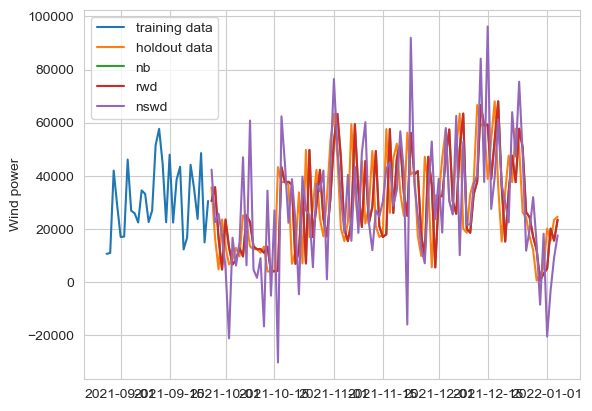

In [32]:
nb = NaiveBaseline()
nb_forecast = []

rwd = RandomWalkWithDrift()
rwd_forecast = []

nswd = NaiveSeasonalWithDrift(season_length=365)
nswd_forecast = []

for i in range(1000, 1100):
    nb.fit(daily.Wind.iloc[:i])
    nb_forecast.append(nb.forecast(1))

    rwd.fit(daily.Wind.iloc[:i])
    rwd_forecast.append(rwd.forecast(1))

    nswd.fit(daily.Wind.iloc[:i])
    nswd_forecast.append(nswd.forecast(1))

plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], nb_forecast, label = 'nb')
plt.plot(daily.index[1000:1100], rwd_forecast, label = 'rwd')
plt.plot(daily.index[1000:1100], nswd_forecast, label = 'nswd')

plt.ylabel('Wind power')
plt.legend()
plt.show()

In [33]:
from statsmodels.tsa.api import ExponentialSmoothing

es_forecast = []
# Fit a "triple exponential smoothing" model with seasonal components.
for i in range(1000, 1100):
    seasonal_exp_smoothing = ExponentialSmoothing(
        daily.Wind.iloc[:i],
        trend=None,              # no trend
        seasonal="add",           # additive seasonality if amplitude is constant
        seasonal_periods=365,      # for monthly data with yearly seasonality
        initialization_method="estimated"  # more stable than "heuristic"
    ).fit()
    es_forecast.append(seasonal_exp_smoothing.forecast(steps=1))

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimizat

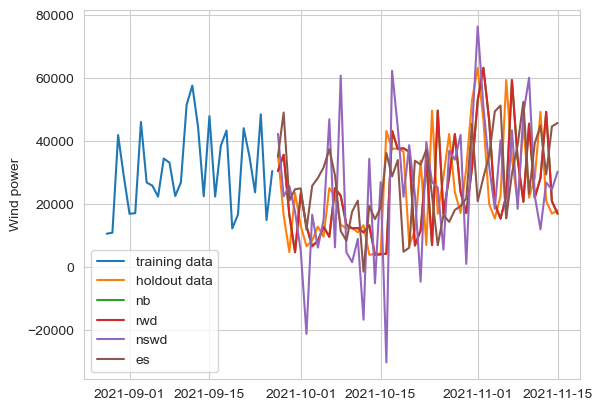

In [34]:
plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1050], daily.Wind.iloc[1000:1050], label = 'holdout data')
plt.plot(daily.index[1000:1050], nb_forecast[:50], label = 'nb')
plt.plot(daily.index[1000:1050], rwd_forecast[:50], label = 'rwd')
plt.plot(daily.index[1000:1050], nswd_forecast[:50], label = 'nswd')
plt.plot(daily.index[1000:1050], es_forecast[:50], label = 'es')

plt.ylabel('Wind power')
plt.legend()
plt.show()

In [35]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape

from sklearn.model_selection import TimeSeriesSplit

In [36]:
season_length = 365
forecast_length = 1
df_train = daily.iloc[:-season_length]

n_splits = 100
kfold = TimeSeriesSplit(n_splits = n_splits,
                           test_size = forecast_length)

nb_mses = np.zeros(n_splits)
rwd_mses = np.zeros(n_splits)
nswd_mses = np.zeros(n_splits)
es_mses = np.zeros(n_splits)

nb_mape = np.zeros(n_splits)
rwd_mape = np.zeros(n_splits)
nswd_mape = np.zeros(n_splits)
es_mape = np.zeros(n_splits)

for i, (train_index, test_index) in enumerate(kfold.split(df_train)):
    ts_tt = df_train.Wind.iloc[train_index]
    ts_ho = df_train.Wind.iloc[test_index]
    
    nb = NaiveBaseline()
    nb.fit(ts = ts_tt)
    nb_preds = nb.forecast(forecast_length)
    nb_mses[i] = mse(ts_ho, nb_preds)
    nb_mape[i] = mape(ts_ho, nb_preds)

    rwd = RandomWalkWithDrift()
    rwd.fit(ts_tt)
    rwd_preds = rwd.forecast(forecast_length)
    rwd_mses[i] = mse(ts_ho, rwd_preds)
    rwd_mape[i] = mape(ts_ho, rwd_preds)

    nswd = NaiveSeasonalWithDrift(season_length=365)
    nswd.fit(ts_tt)
    nswd_preds = nswd.forecast(forecast_length)
    nswd_mses[i] = mse(ts_ho, nswd_preds)
    nswd_mape[i] = mape(ts_ho, nswd_preds)

    es = ExponentialSmoothing(
            ts_tt,
            trend=None,              
            seasonal="add",           # additive seasonality if amplitude is constant
            seasonal_periods=365,      # for daily data with yearly seasonality
            initialization_method="estimated"  # more stable than "heuristic"
        ).fit()
    es_preds = es.forecast(forecast_length)
    es_mses[i] = mse(ts_ho, es_preds)
    es_mape[i] = mape(ts_ho, es_preds)

cv_mse = {'nb':nb_mses, 'rwd':rwd_mses, 'nswd':nswd_mses, 'es': es_mses}
cv_mape = {'nb':nb_mape, 'rwd':rwd_mape, 'nswd':nswd_mape, 'es': es_mape}

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimizat

In [37]:
cv_averages = {name: a.mean() for name, a in cv_mse.items()}
mape_averages = {name: a.mean() for name, a in cv_mape.items()}

print(cv_averages)
print(mape_averages)

{'nb': np.float64(349268607.17), 'rwd': np.float64(349585172.6544649), 'nswd': np.float64(593395620.23), 'es': np.float64(417702349.70960355)}
{'nb': np.float64(0.8813422247413718), 'rwd': np.float64(0.8808954978699752), 'nswd': np.float64(1.291800156573478), 'es': np.float64(1.656797381524932)}


Naive models all have MAPE above 88%!

## (!!! go to ARIMAx.ipynb for better model) ARIMA Model Selection w/ Auto-ARIMA (pmdarima)

Using the auto_arima() function from the pmdarima package, we can perform a parameter search for the optimal values of the model.

In [38]:
import pmdarima as pm
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

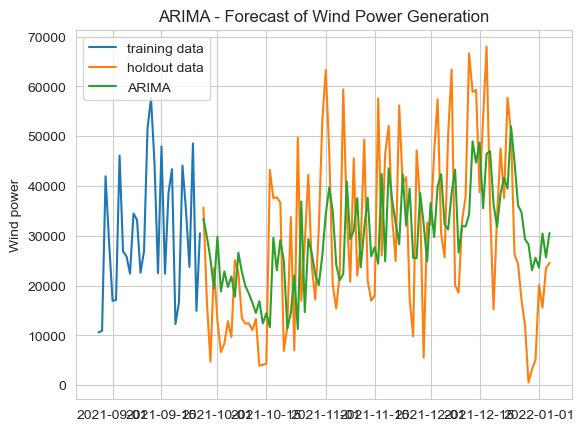

In [40]:
arima_forecast = []
arima_mses = []
arima_mape = []
for i in range(1000, 1100):
    ARIMA_model = pm.auto_arima(daily.Wind.iloc[:i], 
                            start_p=1, 
                            start_q=1,
                            test='adf', # use adftest to find optimal 'd'
                            max_p=7, max_q=7, # maximum p and q
                            m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                            d=None,# let model determine 'd'
                            seasonal=False, # No Seasonality for standard ARIMA
                            trace=False, #logs 
                            error_action='warn', #shows errors ('ignore' silences these)
                            suppress_warnings=True,
                            stepwise=True)
    fitted, confint = ARIMA_model.predict(n_periods=1, return_conf_int=True)
    arima_forecast.append(fitted)
    arima_mses.append(mse(np.array(daily.iloc[i][['Wind']]), fitted))
    arima_mape.append(mape(np.array(daily.iloc[i][['Wind']]), fitted))

plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], arima_forecast, label = 'ARIMA')

plt.title("ARIMA - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()


In [ ]:
np.mean(arima_mape)

np.float64(1.2578268398331263)

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=711.946, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=676.145, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=701.025, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=674.086, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=668.965, Time=0.05 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=668.161, Time=0.11 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=669.518, Time=0.09 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,0,1)(0,0,0)[0]             : AIC=668.986, Time=0.11 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=667.208, Time=0.13 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=651.781, Time=0.15 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.417 seconds
Performing stepwise search to minimize aic


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=650.995, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=653.107, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=653.949, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=649.012, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.532 seconds


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

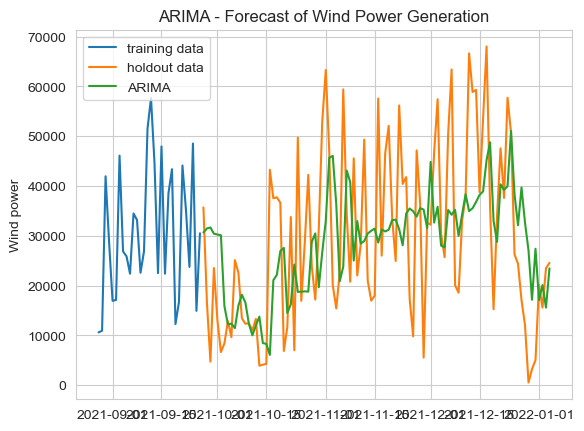

MAPE:  1.2102622497834696


In [ ]:
arima30_forecast = []
arima30_mses = []
arima30_mape = []
for i in range(1000, 1100):
    ARIMA_model = pm.auto_arima(daily.Wind.iloc[i-30:i], 
                            start_p=1, 
                            start_q=1,
                            test='adf', # use adftest to find optimal 'd'
                            max_p=7, max_q=7, # maximum p and q
                            m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                            d=None,# let model determine 'd'
                            seasonal=False, # No Seasonality for standard ARIMA
                            trace=False, #logs 
                            error_action='warn', #shows errors ('ignore' silences these)
                            suppress_warnings=True,
                            stepwise=True)
    fitted, confint = ARIMA_model.predict(n_periods=1, return_conf_int=True)
    arima30_forecast.append(fitted)
    arima30_mses.append(mse(np.array(daily.iloc[i][['Wind']]), fitted))
    arima30_mape.append(mape(np.array(daily.iloc[i][['Wind']]), fitted))

plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], arima30_forecast, label = 'ARIMA')

plt.title("ARIMA - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(arima30_mape))


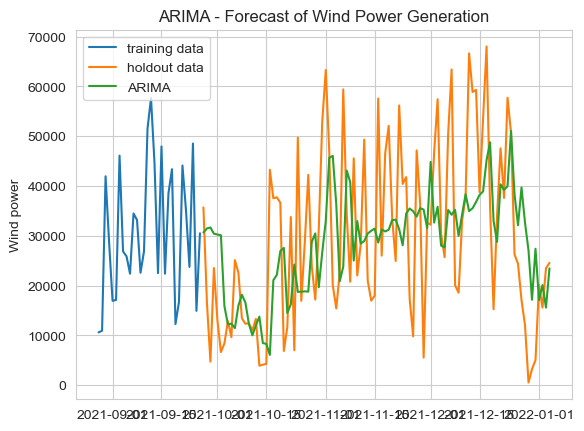

MAPE:  1.2102622497834696


In [ ]:
plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], arima30_forecast, label = 'ARIMA')

plt.title("ARIMA - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(arima30_mape))


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

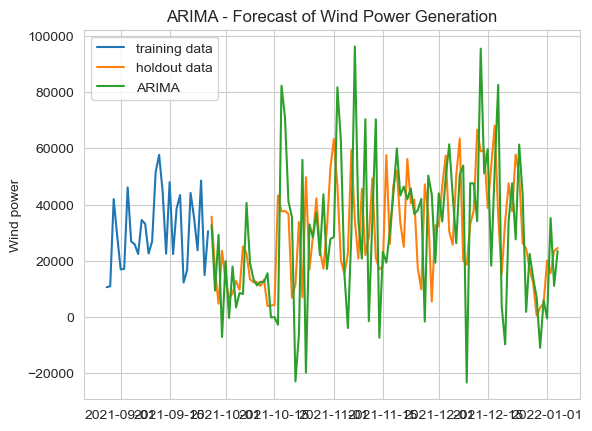

MAPE:  1.0934833433058115


In [ ]:
arima7_forecast = []
arima7_mses = []
arima7_mape = []
for i in range(1000, 1100):
    ARIMA_model7 = pm.auto_arima(daily.Wind.iloc[i-14:i], 
                            start_p=1, 
                            start_q=1,
                            test='adf', # use adftest to find optimal 'd'
                            max_p=7, max_q=7, # maximum p and q
                            m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                            d=None,# let model determine 'd'
                            seasonal=False, # No Seasonality for standard ARIMA
                            trace=False, #logs 
                            error_action='warn', #shows errors ('ignore' silences these)
                            suppress_warnings=True,
                            stepwise=True)
    fitted, confint = ARIMA_model7.predict(n_periods=1, return_conf_int=True)
    arima7_forecast.append(fitted)
    arima7_mses.append(mse(np.array(daily.iloc[i][['Wind']]), fitted))
    arima7_mape.append(mape(np.array(daily.iloc[i][['Wind']]), fitted))

plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], arima7_forecast, label = 'ARIMA')

plt.title("ARIMA - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(arima7_mape))
